In [1]:
import subprocess
from pathlib import Path
from sys import float_info
from collections import defaultdict

import pandas as pd
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm

from dimelo import load_processed

In [2]:
plt.style.use("plots.mpstyle")

# Helper functions

In [ ]:
def generate_genomic_windows(
    genome_index_file: Path,
    window_size: int,
    step_size: int | None = None,
    force: bool = False
) -> Path:
    """
    Generate a bed file containing the specified genomic windows, using `bedtools makewindows`.

    Args:
        genome_index_file: .fai genomic index file specifying the size of each chromosome to generate windows for
        window_size: length of window
        step_size: distance between window starts; if None, set to window_size
        force: force overwrite of existing output bed file
    Returns:
        path to the output bed file
    """
    if step_size is None:
        step_size = window_size
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if force or not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    return window_file

# Peak calling functions

In [4]:
def window_stats(
    window_file: Path,
    pileup_file: Path,
    motif: str,
    cores: int | None = None
) -> pd.DataFrame:
    """
    Load (mod_count, valid_count) for each window from the given pileup.
    
    Returns:
        DataFrame containing 
    """
    # TODO: Do I actually need to store the positions and such?
    df = pd.read_csv(
        window_file,
        sep="\t",
        header=None,
        index_col=False,
        names=["chrom", "chromStart", "chromEnd"]
    )
    mod_count, valid_count = zip(*load_processed.regions_to_list(
        load_processed.pileup_counts_from_bedmethyl,
        window_file,
        bedmethyl_file=pileup_file,
        motif=motif,
        quiet=False,
        cores=cores,
    ))
    df["mod_count"] = mod_count
    df["valid_count"] = valid_count
    # TODO: Do I actually need to store mod_frac?
    # df["mod_frac"] = df["mod_count"] / df["valid_count"]
    return df

In [5]:
def betabinom_loglikelihood(
    params: tuple[float, float],
    k: int,
    n: int
) -> float:
    alpha, beta = params
    ll = stats.betabinom.logpmf(k,n,alpha,beta)
    return -ll.sum()

def fit_betabinom(k: pd.Series, n: pd.Series) -> tuple[float, float]:
    # from https://andrewpwheeler.com/2023/10/18/fitting-beta-binomial-in-python-poisson-scan-stat-in-r/
    # TODO: Nelder-Mead is the only one that has worked in testing; also it is what was referenced above. Is it always a good choice?
    result = optimize.minimize(
        fun=betabinom_loglikelihood,
        x0=[1,1],
        args=(k, n),
        method='Nelder-Mead'
    )
    return tuple(result.x)

def window_probabilities(
    mod_counts: pd.Series,
    valid_counts: pd.Series
) -> pd.Series:
    # Fit a betabinomial
    alpha, beta = fit_betabinom(mod_counts, valid_counts)
    probs = pd.Series([
        1 - stats.betabinom.cdf(k=mod_count, n=valid_count, a=alpha, b=beta)
        for mod_count, valid_count in zip(mod_counts, valid_counts)
    ])
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [6]:
def call_peaks(
    window_file: Path,
    pileup_file: Path,
    motif: str,
    cores: int | None = None
) -> pd.DataFrame:
    df = window_stats(
        window_file,
        pileup_file,
        motif,
        cores
    )
    df["p_value"] = window_probabilities(
        df["mod_count"],
        df["valid_count"],
    )
    return df

# Analysis functions

In [7]:
def window_labels(
    window_file: Path,
    peak_file: Path,
    force: bool = False
) -> pd.Series:
    """
    Labels each window as 1 if it overlaps with at least one peak from the peak file.

    Returns:
        vector of labels in the same order as the window file
    """
    label_file = window_file.with_suffix(".window_labels.tsv")
    if force or not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])["label"]

def window_peak_assignments(
    window_file: Path, 
    ground_truth_peak_file: Path,
    stats_df: pd.DataFrame,
    force: bool = False
) -> pd.Series:
    window_gt_assignment_file = window_file.with_suffix(".window_gt_assignments.tsv")
    if force or not window_gt_assignment_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {ground_truth_peak_file} -wao | cut -f 1-6 > {window_gt_assignment_file}", shell=True)
    window_gt_assignment_df = pd.read_csv(window_gt_assignment_file, sep="\t", header=None, names=["chrom", "chromStart", "chromEnd", "gt_chr", "gt_start", "gt_end"])
    window_gt_assignment_df["gt_ids"] = window_gt_assignment_df[["gt_chr", "gt_start", "gt_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_gt_assignment_df = window_gt_assignment_df[["chrom", "chromStart", "chromEnd", "gt_ids"]].query("gt_ids != '.:-1:-1'").groupby(["chrom", "chromStart", "chromEnd"]).agg({"gt_ids": set}).reset_index()

    ### Calculate ground truth recovery
    with ground_truth_peak_file.open() as fp:
        n_gt_hits = sum(1 for _ in fp)
    window_gt_hits = pd.merge(stats_df, window_gt_assignment_df, how="left", on=["chrom", "chromStart", "chromEnd"])["gt_ids"]
    captured_set = set()
    gt_hits = []
    for gt_set in window_gt_hits:
        if gt_set is not np.nan:
            captured_set = captured_set.union(gt_set)
        gt_hits.append(len(captured_set))
    return stats_df["p_value"].map((pd.Series(gt_hits) / n_gt_hits).groupby(stats_df["p_value"]).last())

In [8]:
def sorted_count_til_row(
    df: pd.DataFrame,
    sort_col: str,
    target_col: str,
    target_value
) -> pd.Series:
    """
    Assuming the given dataframe is sorted by sort_col, returns the number of rows that satisfy the target conditional
    up to that point in sort_col.

    NOTE: This is surprisingly effective and efficient; is it idiomatic?
        How they work: Because it is sorted by probability,
        1. count how many matching labels have been observed up until each row
        2. replace this count with the maximum count observed over all rows with that probability
    """
    return df[sort_col].map((df[target_col] == target_value).expanding().sum().groupby(df[sort_col]).last())

In [9]:
def call_peaks_and_compare_to_ground_truth(
    window_file: Path,
    pileup_file: Path,
    motif: str,
    ground_truth_peak_file: Path,
    force: bool = False,
    cores: int | None = None
) -> pd.DataFrame:
    """
    NOTE: Only works if the windows don't overlap each other (I think...) (i.e. step size == window size)
    """
    peak_df = call_peaks(
        window_file,
        pileup_file,
        motif,
        cores,
    )
    peak_df["label"] = window_labels(
        window_file,
        ground_truth_peak_file,
        force
    )

    # TODO: maybe don't reset the index until the end to make future merges easier
    peak_df = peak_df.sort_values("p_value").reset_index(drop=True)
    # values for each row are the values that correspond to setting the p-value threshold to the value for that row
    positives = peak_df["label"].sum()
    negatives = len(peak_df) - positives
    peak_df["TP"] = sorted_count_til_row(peak_df, "p_value", "label", 1)
    peak_df["FP"] = sorted_count_til_row(peak_df, "p_value", "label", 0)
    peak_df["FN"] = positives - peak_df["TP"]
    peak_df["TN"] = negatives - peak_df["FP"]
    peak_df["TPR"] = peak_df["TP"] / positives
    peak_df["FPR"] = peak_df["FP"] / negatives
    peak_df["precision"] = peak_df["TP"] / (peak_df["TP"] + peak_df["FP"])
    # TODO: Rename this column.
    # contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold (inclusive)
    peak_df["hit_fraction"] = peak_df["p_value"].rank(method="min") / len(peak_df)

    peak_df["Ground Truth Recovery Fraction"] = window_peak_assignments(
        window_file, 
        ground_truth_peak_file,
        peak_df,
        force
    )
    return peak_df

In [10]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"p_value < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"p_value < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"p_value < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")

def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["p_value"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction vs. threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["p_value"], labeled_stats_df["Ground Truth Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ground truth peaks recovered")
    axs[1].set_title("ground truth peak recovery vs. threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"p_value < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['Ground Truth Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)

In [11]:
def compare_independent_variable(
    dfs: list[pd.DataFrame],
    independent_variable_settings: list,
    independent_variable_name: str
):
    _, axs = plt.subplots(2, 2, layout="constrained", figsize=(8, 8))
    roc_aucs = []
    prc_aucs = []
    for window_size, labeled_stats_df in zip(independent_variable_settings, dfs):
        roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
        prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])
        roc_aucs.append(roc_auc)
        prc_aucs.append(prc_auc)

        axs[0][0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"{window_size}bp (AUC={roc_auc:.2})")

        axs[0][1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"{window_size}bp (AUC={prc_auc:.2})")
        # baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
        # axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    axs[1][0].plot(independent_variable_settings, roc_aucs)
    y_min, y_max = axs[1][0].get_ylim()
    roc_auc_max_window = independent_variable_settings[roc_aucs.index(max(roc_aucs))]
    axs[1][0].vlines(x=roc_auc_max_window, ymin=y_min, ymax=y_max, color="black", linestyle="--", label=f"{roc_auc_max_window}")

    axs[1][1].plot(independent_variable_settings, prc_aucs)

    axs[0][0].set_title("ROC")
    axs[0][0].legend(loc="lower right")
    axs[0][0].set_xlabel("FPR")
    axs[0][0].set_ylabel("TPR")
    axs[0][0].set_box_aspect(1)

    axs[0][1].set_title("precision-recall curve")
    axs[0][1].legend(loc="best")
    axs[0][1].set_xlabel("recall")
    axs[0][1].set_ylabel("precision")
    axs[0][1].set_box_aspect(1)

    axs[1][0].set_title(f"ROC AUC vs. {independent_variable_name}")
    axs[1][0].legend()
    axs[1][0].set_box_aspect(1)

    axs[1][1].set_title(f"PRC AUC vs. {independent_variable_name}")
    axs[1][1].set_box_aspect(1)

    # plt.suptitle(mod_prob_threshold)

In [12]:
def grid_search_heatmap(
    mod_prob_thresholds: list,
    window_sizes: list,
    value_function,
    vals_label: str,
    results_dict: dict[float, dict[float, pd.DataFrame]]
):
    x_vals = []
    y_vals = []
    vals = []
    for window_size in window_sizes:
        for mod_prob_threshold in mod_prob_thresholds:
            x_vals.append(mod_prob_threshold)
            y_vals.append(window_size)
            labeled_stats_df = results_dict[mod_prob_threshold][window_size]
            vals.append(value_function(labeled_stats_df))
    x_label = "modification probability threshold"
    y_label = "window size"
    sns.heatmap(pd.DataFrame({x_label: x_vals, y_label: y_vals, vals_label: vals}).pivot(index=y_label, columns=x_label, values=vals_label), cmap="mako", cbar_kws={"label": vals_label})


# Set variables

In [8]:
output_dir = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/peak_calling/")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
# pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
pileup_id = "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10"
ctcf_chip_seq_file = output_dir / "chr11_ctcf_chip_peaks.bed"
genome_index_file = output_dir / "chr11.fai"

# parallel arrays
window_sizes = [500, 1000, 1500, 2000, 5000, 10000]
step_sizes = window_sizes

mod_prob_thresholds = [0.1, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9]
motif = "A,0"
p_threshold = 0.05

# Run peak calling

Run a grid search over settings (window size, mod-prob threshold)

In [14]:
# Store results keyed as results_dict[mod_prob_threshold][window_size]
results_dict = defaultdict(dict)
# for mod_prob_threshold in mod_prob_thresholds:
for mod_prob_threshold in tqdm(mod_prob_thresholds, unit="mod_prob_threshold"):
    pileup_file = output_dir / f"{pileup_id}.{mod_prob_threshold}" / "pileup.sorted.bed.gz"
    # for window_size in window_sizes:
    for window_size in tqdm(window_sizes, unit="window_size"):
        window_file = generate_genomic_windows(
            genome_index_file,
            window_size,
            step_size=window_size
        )
        results_dict[mod_prob_threshold][window_size] = call_peaks_and_compare_to_ground_truth(
            window_file,
            pileup_file,
            motif,
            ctcf_chip_seq_file,
            cores=8
        )

  0%|          | 0/8 [00:00<?, ?mod_prob_threshold/s]

  0%|          | 0/6 [00:00<?, ?window_size/s]

Loading data:   0%|          | 0/270256 [00:00<?, ?it/s]

Loading data:   0%|          | 0/135128 [00:00<?, ?it/s]

Loading data:   0%|          | 0/90086 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/135128 [00:00<?, ?it/s]

Loading data:   0%|          | 0/90086 [00:00<?, ?it/s]

Loading data:   0%|          | 0/67564 [00:00<?, ?it/s]

Loading data:   0%|          | 0/27026 [00:00<?, ?it/s]

Loading data:   0%|          | 0/13513 [00:00<?, ?it/s]

# Plot grid search results

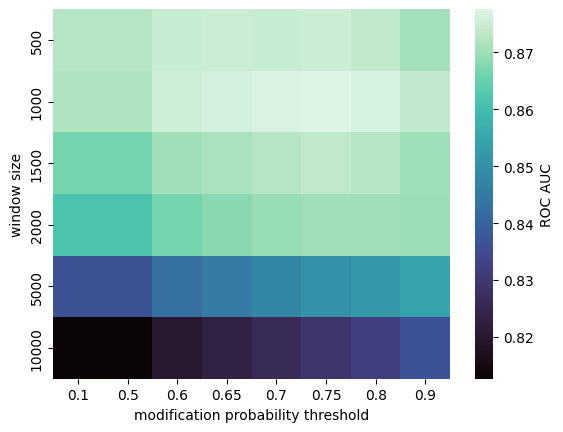

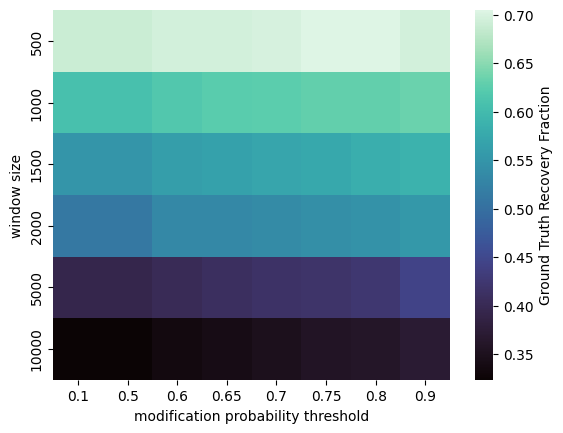

In [17]:
grid_search_heatmap(
    mod_prob_thresholds,
    window_sizes,
    lambda df: np.trapezoid(df["TPR"], df["FPR"]),
    "ROC AUC",
    results_dict
)
plt.show()
plt.close()

grid_search_heatmap(
    mod_prob_thresholds,
    window_sizes,
    lambda df: df.query(f"p_value < {p_threshold}").iloc[-1]["Ground Truth Recovery Fraction"],
    "Ground Truth Recovery Fraction",
    results_dict
)
plt.show()
plt.close()

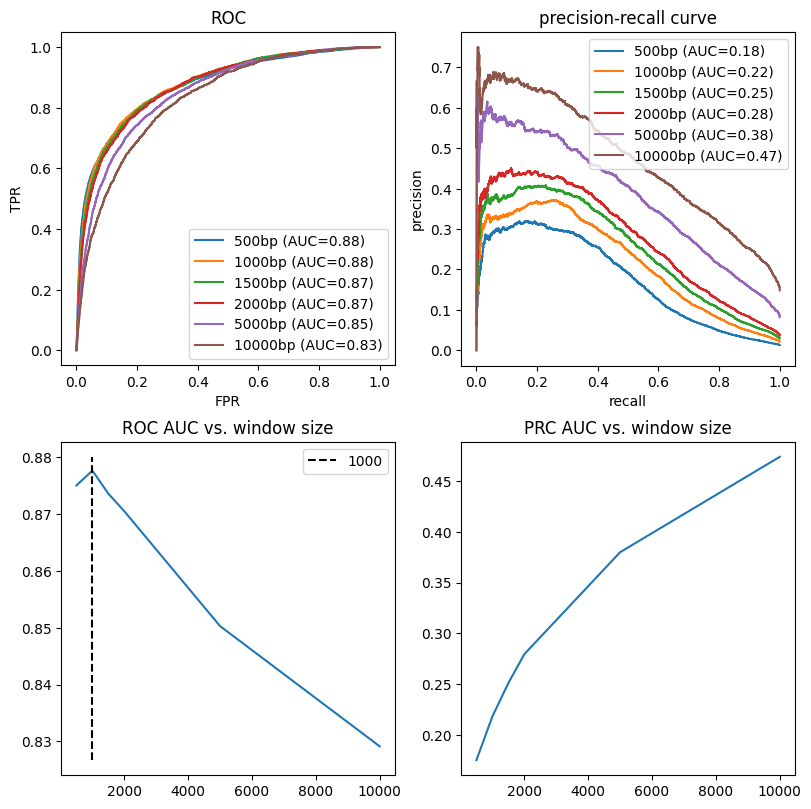

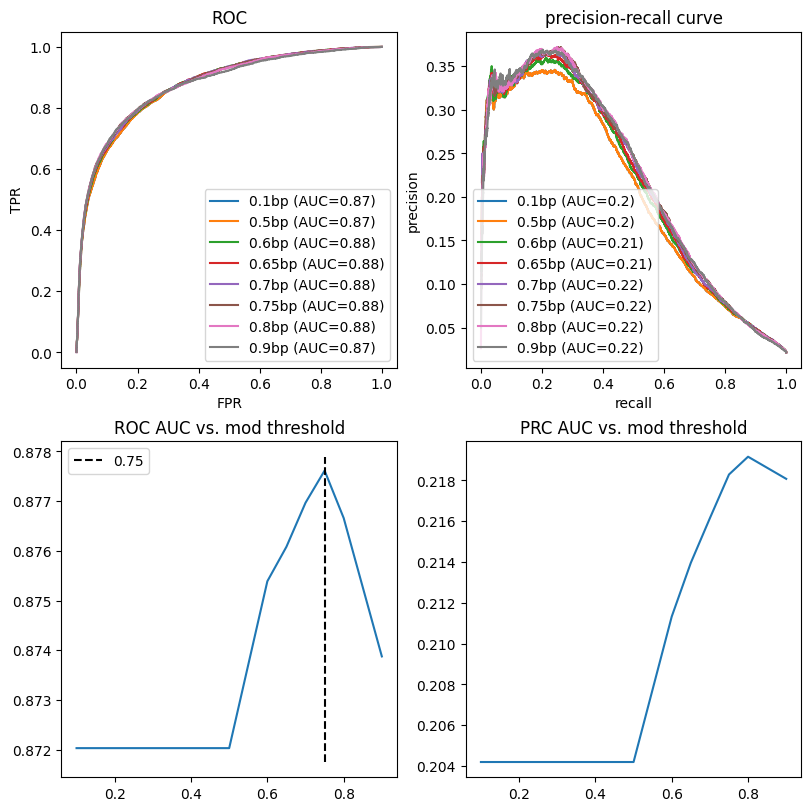

In [18]:
compare_independent_variable([results_dict[0.75][window_size] for window_size in window_sizes], window_sizes, "window size")
plt.show()
plt.close()
compare_independent_variable([results_dict[thresh][1000] for thresh in mod_prob_thresholds], mod_prob_thresholds, "mod threshold")
plt.show()
plt.close()

# Explore performance with chosen settings

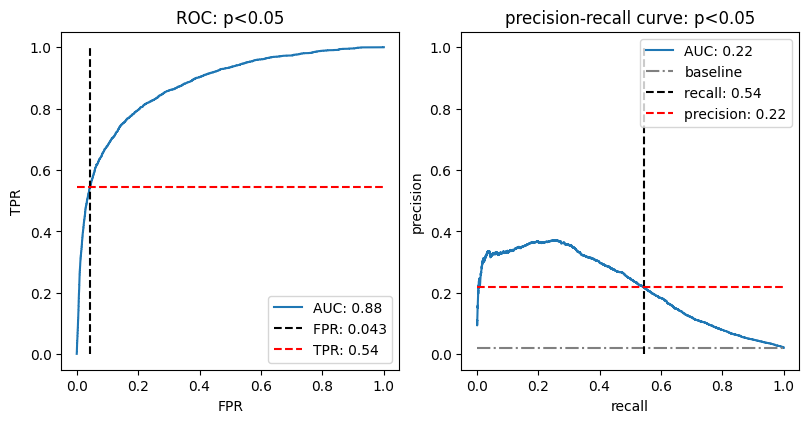

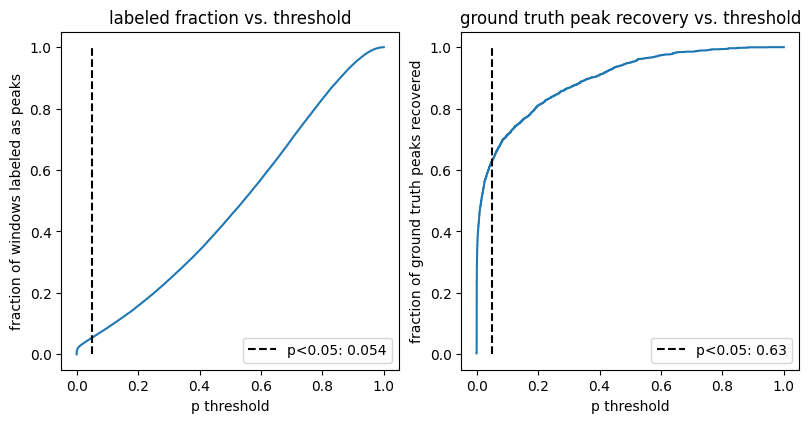

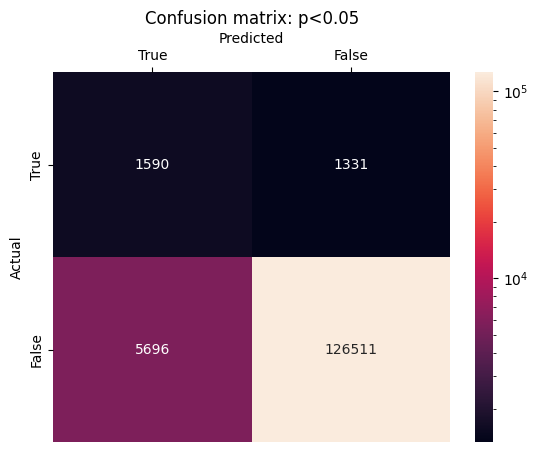

In [19]:
roc_prc_plot(results_dict[0.75][1000], p_threshold)
plt.show()
plt.close()
peak_label_plots(results_dict[0.75][1000], p_threshold)
plt.show()
plt.close()
confusion_matrix_plot(results_dict[0.75][1000], p_threshold)
plt.show()
plt.close()

## Validate model fit

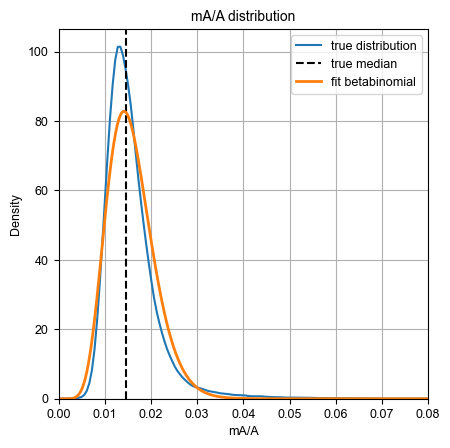

In [ ]:
window_file = generate_genomic_windows(
    genome_index_file,
    1000
)

window_stats_df = window_stats(
    window_file,
    output_dir / f"{pileup_id}.0.75" / "pileup.sorted.bed.gz",
    "A,0"
)
window_stats_df["mod_frac"] = window_stats_df["mod_count"] / window_stats_df["valid_count"]

bb_params = fit_betabinom(window_stats_df["mod_count"], window_stats_df["valid_count"])

sns.kdeplot(x=window_stats_df["mod_frac"], label="true distribution")
plt.axvline(window_stats_df["mod_frac"].median(), label='true median', color="black", linestyle="--")
x = np.linspace(0, 0.08, 500)
params = bb_params
label = "fit betabinomial"
plt.plot(x, stats.beta.pdf(x, *params), label=label, lw=2)
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.gca().set_box_aspect(1)
plt.savefig("peakcalling_model_distribution.svg")
plt.show()
plt.close()